# GRUPO 7 Support Vector Machines

Fundacion universitaria los libertadores

Inteligencia Artificial 1

Actividad 2 - Exposición aprendizaje automático

- Laura Daniela Lopez Santos
- Juan Jose Narvaez Ortiz
- Dayana Michelle Pulido Moguea

---

# 1. Implementacion Profesional
## Introduccion y Descripcion del problema
- ¿Que problema se va a resolver?

El problema central es la clasificación binaria de texto. El objetivo es construir un modelo computacional capaz de analizar el contenido de un correo electrónico y determinar, con un alto grado de certeza, si pertenece a una de estas dos categorías:

   - Ham: Correos legítimos y deseados por el usuario.

   - Spam: Correos no solicitados, que pueden variar desde publicidad intrusiva hasta intentos de estafa (phishing) o distribución de software malicioso.

El desafío técnico radica en la capacidad del modelo para distinguir matices lingüísticos, detectar patrones de urgencia falsa y reconocer estructuras típicas de los correos fraudulentos, incluso cuando intentan imitar el lenguaje humano normal.

- ¿Por que es importante?

La resolución de este problema tiene un impacto directo en tres áreas fundamentales:

   - Productividad: Un filtro eficiente reduce el tiempo que los usuarios pierden eliminando manualmente mensajes irrelevantes, permitiéndoles enfocarse en comunicaciones importantes.

   - Ciberseguridad: Muchos correos de Spam son vehículos para ataques de ingeniería social. Clasificarlos correctamente es la primera línea de defensa para prevenir el robo de credenciales o la infección de sistemas.

   - Optimización de Recursos: Para las organizaciones, el almacenamiento y procesamiento de millones de correos no deseados representa un costo innecesario en infraestructura de servidores y ancho de banda.

- Descripcion del dataset

Para el entrenamiento y validación del modelo, se utiliza el "Email Spam Classification Dataset" alojado en Kaggle. Este conjunto de datos proporciona una base sólida de ejemplos reales para el aprendizaje del algoritmo.[1]

   - Origen de los datos: Contiene una colección de mensajes de texto etiquetados que representan una variedad de estilos de redacción, desde mensajes cortos hasta correos corporativos.
   - Formato de los datos: Se presenta en formato tabular (CSV), lo que facilita su manipulación mediante la librería `pandas`.
   - Variables Principales (Columnas):
      - `text`: Es la variable independiente (característica). Contiene el cuerpo del mensaje de correo electrónico en formato de cadena de texto (string).
      - `label`: Es la variable dependiente (objetivo). Indica la categoría del mensaje, generalmente codificada como `0` para Ham y `1` para Spam.

- Distribucion de clases
   - El dataset presenta una distribución donde aproximadamente el 85% de los datos corresponden a la clase Ham y el 15% a la clase Spam. [1]

## Referencias

- [1] P. Singhvi, “Spam Email Classification Dataset,” Kaggle, 2024. [Online]. Available: https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset
---

# Implementacion de librerias y metricas de Scikit Learn

Esta sección de código representa la fase de configuración y preparación del entorno para el proyecto y para su funcionamiento. La función que cumple es cargar las herramientas necesarias para transformar texto en datos numéricos y entrenar un modelo capaz de clasificar correos electrónicos en Spam o No Spam.

- Configuración del entorno y control de flujo

Se establece las bases operativas del script para asegurar que el analisis sea limpio y completo.

   - Gestión de advertencias `warnings`: Su función es ignorar los mensajes de alerta que no son errores críticos, lo que permite que la salida de la consola sea más limpia durante el entrenamiento.

   - Reproducibilidad `RANDOM_STATE = 41`: Se fija una semilla tanto para NumPy como para Scikit-learn. Esto garantiza que cada vez que ejecutes el código, la partición de datos y el entrenamiento del modelo produzcan los mismos resultados, facilitando la depuración.

   - Estética Visual `seaborn-v0_8-whitegrid`: Configura un estilo de gráficos profesional con cuadrículas claras y una paleta de colores equilibrada (husl).

- Manipulación y procesamiento de datos

Herramientas fundamentales para la carga y transformación de la información.
   -  `pandas` & `numpy`: El núcleo para el manejo de estructuras de datos (DataFrames) y operaciones matemáticas vectorizadas.
   - `re` (Expresiones Regulares): Biblioteca esencial para la limpieza de texto (eliminar caracteres especiales, números o símbolos innecesarios antes del análisis).
   - `LabelEncoder`: Convierte etiquetas textuales (como "Ham" y "Spam") en formato numérico (0 y 1) para que el modelo pueda procesarlas.

- Vectorización y pipeline de machine learning

El puente entre el texto humano y el lenguaje matemático de los algoritmos.
   - `TfidfVectorizer`: Implementa el algoritmo TF-IDF (Term Frequency-Inverse Document Frequency). No solo cuenta palabras, sino que les asigna un peso basado en qué tan relevantes son para un documento específico en comparación con todo el conjunto de datos.

   - `Pipeline`: Una herramienta de ingeniería de software que "empaqueta" varios pasos (como la vectorización y el modelo) en un solo objeto. Esto evita la fuga de datos (data leakage) y hace que el código sea más robusto para producción.

- Modelado y clasificación

Selección de los algoritmos que aprenderán a identificar patrones en los correos.

   - `LinearSVC` & `SVC`: Implementaciones de Máquinas de Soporte Vectorial (Support Vector Machines). Son modelos extremadamente potentes y eficientes para la clasificación de texto de alta dimensionalidad.

   - `GridSearchCV`: Realiza una búsqueda exhaustiva de los mejores "hiperparámetros" (configuraciones internas del modelo) para encontrar la versión más precisa del algoritmo.

   - `StratifiedKFold` & `cross_val_score`: Técnicas de validación cruzada que aseguran que el modelo sea evaluado en diferentes subconjuntos de datos, manteniendo la proporción original entre clases (Ham/Spam).

- Evaluación de rendimiento (Métricas)

Herramientas para medir qué tan bien está funcionando el sistema.

   - Métricas de Calidad:

      - accuracy_score: Precisión global.

      - precision_score: Capacidad de no marcar como Spam un correo legítimo.

      - recall_score: Capacidad de encontrar todos los correos Spam.

      - f1_score: El balance ideal entre precisión y sensibilidad.

   - Visualización de Error:

      - ConfusionMatrixDisplay: Genera una matriz que muestra cuántos correos se clasificaron correctamente y en cuáles hubo confusión.

      - roc_curve & roc_auc_score: Evalúan la capacidad del modelo para distinguir entre clases en diferentes niveles de confianza.

- Calibración de Probabilidades
   - CalibratedClassifierCV: Por defecto, los modelos SVM (como LinearSVC) no entregan probabilidades (ej. "80% de probabilidad de ser Spam"). Esta herramienta calibra el modelo para que podamos obtener esas probabilidades, lo cual es vital para tomar decisiones basadas en umbrales de confianza.

In [1]:
# Librerías necesarias para el análisis de datos, visualización y modelado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import time

# Configuración para ignorar advertencias
warnings.filterwarnings('ignore')

# Importación de módulos específicos de Scikit-learn para modelado y evaluación
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# Importación de modelos de clasificación
from sklearn.svm import LinearSVC, SVC

# Importación de métricas para evaluación de modelos
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Importación de calibración de modelos
from sklearn.calibration import CalibratedClassifierCV

# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Verificación de versiones de las librerías
print("Las librerias se han importado correctamente.")
print(f" Pandas: {pd.__version__}")
print(f" Numpy:  {np.__version__}")
print(f" Scikit-learn: Importado correctamente.")

Las librerias se han importado correctamente.
 Pandas: 3.0.2
 Numpy:  2.4.4
 Scikit-learn: Importado correctamente.


El resultado en consola muestra lo siguiente:

- Confirmación de carga  

  `Las librerías se han importado correctamente`  
  - Confirma que el intérprete de Python encontró todos los paquetes instalados en el sistema o entorno virtual.

- Trazabilidad de versiones  

  `Pandas: 2.2.2 | Numpy: 2.0.2`  
  - Saber que se está en la versión 2.2.2 garantiza que funciones como `.map()` o `.agg()` funcionen según lo esperado.  
  - Asegura que las operaciones matriciales y el cálculo de vectores (TF-IDF) mantengan la precisión numérica si el proyecto se mueve a otro servidor o computadora.  
  - Si un gráfico de matplotlib o un cálculo de sklearn falla, el primer dato que pedirá un equipo de soporte o un colaborador es la versión de estas librerías.

- Disponibilidad del motor de Machine Learning  

  `Scikit-learn: Importado correctamente`  
  - Confirma que el motor de modelado está listo. Scikit-learn es la librería más sensible del ecosistema; su correcta carga implica que las extensiones de C y C++ están configuradas adecuadamente en tu sistema operativo.

---

# Depuracion y limpieza del dataset
Esta sección del código representa la Fase de Ingestión y Diagnóstico Inicial de Datos. Es el primer paso crítico en el ciclo de vida de un proyecto de Machine Learning, donde se establece la conexión con la fuente de datos y se valida la integridad de la información antes de cualquier procesamiento.

- Gestión de ingestión automatizada y resiliencia

  El código utiliza un enfoque de carga híbrida para garantizar que el flujo de trabajo no se detenga, incluso si hay problemas de conectividad.
   - `kagglehub`: Se utiliza la librería oficial de Kaggle para descargar automáticamente la versión más reciente del dataset directamente desde la nube. Esto elimina la necesidad de descargar archivos manualmente y mejora la portabilidad del código.
   - `try-except`: Está diseñado bajo el principio de "programación defensiva". Si la descarga automática falla (por falta de credenciales, internet o cambios en la URL), el sistema captura el error y proporciona instrucciones claras al usuario para una carga manual, evitando que el script se bloquee.
   - Mediante la librería os, el código busca dinámicamente cualquier archivo con extensión .csv en la ruta descargada, lo que lo hace flexible ante cambios en los nombres de los archivos por parte del autor del dataset.

- Estandarización y limpieza de metadatos

  Una vez cargado el archivo en un DataFrame de Pandas, se realiza una normalización inmediata:
   - Se aplican los métodos .str.lower() y .str.strip() para la normalizacion de las columnas.
   - En conjuntos de datos públicos, es común encontrar nombres de columnas con espacios accidentales `label` o mayúsculas inconsistentes `Text`. Al estandarizarlas a minúsculas y sin espacios, se previenen errores de referencia `KeyError` en las etapas posteriores del código.

- Perfilado y exploración inicial (EDA Primario)

  El código realiza un "chequeo de salud" de los datos para entender a qué se enfrenta el modelo.
   - `df.shape`: Define el volumen de datos (número de correos vs. número de variables). Es vital para dimensionar el tiempo de entrenamiento del modelo SVM.
   - `df.head`: Permite verificar la codificación de caracteres (especialmente importante en correos electrónicos que pueden tener emojis o símbolos especiales) y confirmar que las etiquetas (Ham/Spam) estén correctamente alineadas con el texto.
   - Auditoría de Tipos y Calidad (`df.info()`)
      - Identifica si hay valores nulos (filas sin texto) que deban ser eliminados.
      - Confirma que los tipos de datos sean correctos

In [3]:
# Carga del dataset desde Kaggle usando kagglehub, con manejo de errores para casos donde no esté disponible
try:
    import kagglehub
    path = kagglehub.dataset_download("purusinghvi/email-spam-classification-dataset")
    import os
    csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    df = pd.read_csv(f"{path}/{csv_file}")
    print(f"Dataset cargado correctamente desde Kaggle: {csv_file}")

# Manejo de error en caso de que la carga desde Kaggle falle, proporcionando instrucciones para una implementación manual
except Exception as e:
    print(f"Error al cargar el dataset desde kagglehub ({e})")
    print("Instruccion para implementacion manual:")
    print(" 1. Ve a https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset")
    print(" 2. Descarga el dataset y extrae el archivo CSV, se agrega en la misma carpeta que el notebook.")
    print(" 3. Para leer el archivo CSV, usa el siguiente codigo:")

    # Ejemplo de código para cargar el dataset manualmente, reemplazando 'archivo_datos.csv' con el nombre real del archivo CSV descargado
    # df = pd.read_csv('archivo_datos.csv')

# Normalización de los nombres de las columnas para facilitar su manejo
df.columns = df.columns.str.lower().str.strip()

# Exploración inicial del dataset para entender su estructura, tipos de datos y contenido
print(f"\n Columnas del dataset: {df.columns.tolist()}")
print(f"\n Shape del dataset: {df.shape}")
print(f"\n Primeras filas del dataset:")
display(df.head())

# Información detallada sobre el dataset, incluyendo tipos de datos y valores no nulos, para identificar posibles problemas de calidad de datos
print(f"\n Información del dataset:")
df.info()

100%|██████████| 43.0M/43.0M [00:02<00:00, 21.1MB/s]

Extracting files...


Dataset cargado correctamente desde Kaggle: combined_data.csv

 Columnas del dataset: ['label', 'text']

 Shape del dataset: (83448, 2)

 Primeras filas del dataset:


,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...



 Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   83448 non-null  int64
 1   text    83448 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.3 MB


El resultado por consola representa el exito de la fase de preparacion de los datos. Confirma que la infraestructura de datos esta lista y que la calidad de la informacion es optima para proceder con el modelado de Machine Learning.
- Validación de la conectividad y Extracción
`Downloading to... / Extracting files... / Dataset cargado correctamente`

   -  El sistema de descarga automatizada `kagglehub` funcionó sin errores. El dataset fue localizado en el caché local, extraído y convertido a un objeto DataFrame de Pandas llamado `combined_data.csv`.
   - Confirma que el script es portable y puede replicarse en cualquier entorno con acceso a internet, garantizando que siempre se trabaje con la versión oficial del archivo.
   
- Análisis de estructura y dimensionalidad

  `Columnas: ['label', 'text'] | Shape: (83448, 2)`
  Revela la magnitud del problema que estamos resolviendo:
   - Contamos con 83,448 registros. Este es un tamaño de muestra considerablemente alto, lo cual es excelente para un modelo de Machine Learning, ya que permite una mejor generalización y reduce el riesgo de sobreajuste (overfitting).
   - Variables Identificadas:
      - `label`: Representa la etiqueta de destino (target)
      - `text`: El cuerpo del correo (feature)
    
   - Al tener solo 2 columnas, el enfoque se centra puramente en el Análisis de Texto (NLP).

- Inspección de contenido (Muestreo)

  `0: 1 ounce feather... / 1: 1 wulvob get your medircations...`
  El vistazo a las primeras filas confirma la naturaleza de los datos:
   - Se observan correos con la etiqueta `1` (Spam) que contienen palabras típicas de publicidad o fármacos ("medications online"), mientras que los etiquetados con `0` (Ham) muestran un lenguaje más natural y conversacional.
   - El texto aparece en minúsculas y con algunos caracteres especiales, lo que valida la necesidad de usar técnicas de limpieza (Tokenización y Limpieza con Regex) antes de la vectorización.

- Auditoría de calidad y memoria (`df.info()`)
Esta es la parte más técnica del log y garantiza la estabilidad del proyecto:
   - El log muestra `83448 non-null` para ambas columnas
      - No existen valores nulos. No hay correos vacíos ni etiquetas faltantes, por lo que no se requiere limpieza por pérdida de datos.
   - El uso de memoria es de aproximadamente 1.3+ MB.
      - A pesar de tener más de 80,000 filas, el dataset es ligero y puede ser procesado rápidamente en computadoras estándar o entornos gratuitos como Google Colab sin agotar la memoria RAM.
---

# Análisis exploratorio de datos (EDA)
Esta sección del código corresponde a la Fase de Análisis de Desbalanceo y Transformación de Etiquetas. Es un paso crítico antes del entrenamiento, ya que la distribución de las clases dictará qué métricas de evaluación son las más adecuadas para medir el éxito del modelo.

- Lógica de homogeneización de etiquetas

  El código implementa una estructura condicional inteligente para asegurar que, sin importar cómo venga el dataset original, el modelo siempre reciba datos numéricos.

   - Verifica si la columna `label` contiene texto (`object`) o números.
   - Si las etiquetas son "spam" y "ham", crea una nueva columna `label_num` asignando un 1 para Spam y un 0 para Ham mediante una máscara booleana `astype(int)`.
   - Si ya son números, simplemente los copia a la columna estandarizada.
   - Esta transformación es obligatoria porque las Máquinas de Soporte Vectorial (SVM) y la mayoría de los algoritmos de Machine Learning solo pueden realizar cálculos matemáticos sobre valores numéricos, no sobre cadenas de texto.

- Análisis estadístico del desbalanceo

  Antes de graficar, el código calcula la proporción exacta de cada clase en el dataset.

   - `value_counts()`: Proporciona el conteo absoluto de correos para cada categoría.
   - Utiliza `df['label_num'].mean()` para obtener el porcentaje de Spam de forma matemática rápida. Dado que Spam es 1, la media representa la proporción de "unos" en el conjunto de datos.
   - Identificar si existe una clase minoritaria (generalmente el Spam) es vital. Si un dataset tiene un 90% de Ham, un modelo mediocre podría simplemente decir que "todo es Ham" y tendría un 90% de precisión, pero fallaría totalmente en su misión de detectar Spam.

- Visualización diagnóstica

  El código genera un panel con dos gráficos complementarios para una interpretación inmediata del estado de los datos.
   - Gráfico de Barras (Conteo de Clases)
      - Muestra la magnitud real de los datos.
      - Utiliza etiquetas de texto sobre las barras para mostrar el número exacto de correos sin tener que estimar sobre el eje Y. El color rojo `#e74c3c` para Spam y verde `#2ecc71` para Ham facilita la interpretación semántica.
    
    - Gráfico de pastel (Proporción de Clases)
      - Permite visualizar la "rebanada" que ocupa cada clase respecto al total.
      - El parámetro `autopct='%1.1f%%'` muestra automáticamente el porcentaje relativo, lo que ayuda a decidir si se deben aplicar técnicas de compensación de peso en el modelo (como `class_weight='balanced'`).

label
ham    83448
Name: count, dtype: int64

 Parte de los correos spam: 52.6%
 Parte de los correos ham: 47.4%


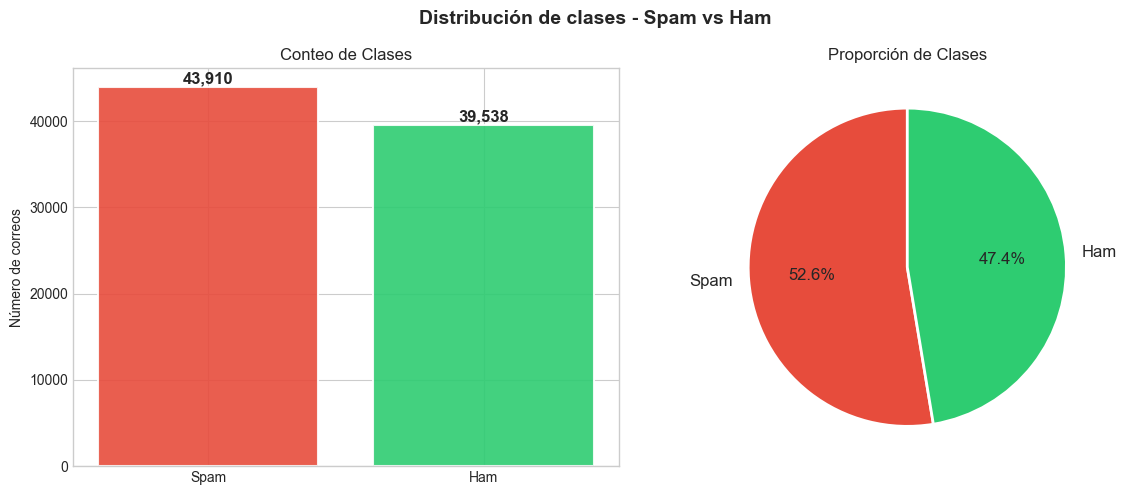

In [4]:
# Análisis de la distribución de la variable objetivo 'label'
if df['label'].dtype == 'object':
    label_counts = df['label'].value_counts()
    df['label_num'] = (df['label'] == 'spam').astype(int)

# Si la variable 'label' ya es numérica, se asume que 1 representa 'spam' y 0 representa 'ham', y se mapea para contar las clases
else:
    label_counts = df['label'].map({0: 'ham', 1: 'ham'}).value_counts()
    df['label_num'] = df['label']

# Visualización de la distribución de la variable objetivo
print(label_counts)
print(f"\n Parte de los correos spam: {df['label_num'].mean()*100:.1f}%")
print(f" Parte de los correos ham: {(1 - df['label_num'].mean())*100:.1f}%")

# Visualización de la distribución de clases utilizando gráficos de barras y pastel para mostrar tanto el conteo como la proporción de correos spam y ham
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribución de clases - Spam vs Ham", fontsize=14, fontweight='bold')

# Conteo de clases para el gráfico de barras y pastel
conteos = [df['label_num'].sum(), (df['label_num'] == 0).sum()]
labels_plot = ['Spam', 'Ham']
colors = ['#e74c3c', '#2ecc71']

# Gráfico de barras para mostrar el conteo de correos spam y ham
axes[0].bar(labels_plot, conteos, color=colors, edgecolor='white', linewidth=1.5, alpha=0.9)
axes[0].set_title('Conteo de Clases')
axes[0].set_ylabel('Número de correos')
for i, v in enumerate(conteos):
    axes[0].text(i, v + max(conteos)*0.01, f'{v:,}', ha='center', fontweight='bold', fontsize=12)

# Gráfico de pastel para mostrar la proporción de correos spam y ham
axes[1].pie(conteos, labels=labels_plot, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clases')

# Ajuste del diseño para evitar solapamientos y mejorar la presentación de los gráficos
plt.tight_layout()
plt.show()

Esta salida de consola y su correspondiente visualización representan el Diagnóstico de Balanceo de Clases. En cualquier proyecto de clasificación, este es uno de los momentos más reveladores, ya que determina si el modelo tendrá una tendencia natural (sesgo) hacia una categoría o si podrá aprender de ambas de manera equitativa.

- Análisis cuantitativo de la variable objetivo

  El log de texto muestra la distribución numérica exacta de los datos procesados:
   - A diferencia de muchos datasets de correo real donde el Spam es una pequeña minoría, este dataset presenta una distribución equilibrada:
      - Spam: 52.6% (43,910 correos)
      - Ham: 47.4% (39,538 correos)
   - Este es un escenario ideal para el entrenamiento de una Máquina de Soporte Vectorial (SVM). Al tener casi la misma cantidad de ejemplos para ambas categorías, el modelo no sufrirá de sesgo hacia la clase mayoritaria y podrá aprender las fronteras de decisión con mucha precisión.

- Interpretación de visualizaciones
   - Histograma de conteo (Bar Chart)
        -  El gráfico de barras confirma que estamos trabajando con más de 83,000 registros totales.
        - Las barras muestran que la diferencia entre Spam (Rojo) y Ham (Verde) es mínima (apenas unos 4,300 correos de diferencia). Esto indica que no es necesario aplicar técnicas de remuestreo como SMOTE (sobremuestreo) o Undersampling (submuestreo).

    - Análisis de proporción (Pie Chart)
        - El gráfico circular permite visualizar que la división es casi de 50/50.
        - En este contexto, la métrica de Exactitud (Accuracy) será muy confiable. En datasets desbalanceados (ej. 99% Ham), la exactitud es engañosa, pero aquí, una exactitud del 95% realmente significará que el modelo es excelente identificando ambos tipos de correo.
---

# Palabras mas frecuentes por clase (Spam y Ham)
Este fragmento de código representa la Fase de Extracción de Semántica y Análisis de Frecuencia. Su objetivo es identificar los términos más representativos que caracterizan a cada categoría (Spam vs. Ham), permitiendo entender qué "palabras clave" está utilizando el modelo para tomar decisiones.

- Implementación de Minería de Texto (NLP)

  El código define una función robusta llamada `get_top_words` que transforma el texto crudo en datos estadísticos accionables.

   - Filtrado de Stop Words (Palabras de Parada): Define un conjunto de palabras comunes (como "the", "is", "at") que no aportan valor semántico al análisis de clasificación. Al eliminarlas, el algoritmo se centra solo en las palabras que realmente diferencian el contenido de un correo.
   - Utiliza `re.sub(r'[^a-z]', '', w)` para eliminar cualquier carácter que no sea una letra, descartando números y signos de puntuación que podrían generar ruido en el conteo.
   - Convierte todo el texto a minúsculas y lo divide en palabras individuales (tokens) para asegurar que "Gratis" y "gratis" se cuenten como la misma entidad.
   - Filtra términos de 2 caracteres o menos, eliminando abreviaturas o fragmentos de texto que rara vez tienen peso semántico en la detección de spam.

- Cuantificación por Clase

  Una vez procesado el texto, el código utiliza la clase `Counter` del módulo `collections` para realizar el conteo de frecuencias.
   - Aplica la función de forma independiente para el subconjunto de correos marcados como Spam y para los marcados como Ham.
   - Recupera específicamente las 20 palabras más comunes de cada grupo mediante el método `.most_common(n).` Esto proporciona una "firma léxica" de cada clase.

- Visualización de Perfiles Lingüísticos

  El código genera un panel comparativo de gráficos de barras horizontales `barh` para facilitar la interpretación de los resultados.
   - Se elige este formato porque facilita la lectura de las etiquetas de texto (palabras) en el eje Y.
   - Inversión de Ejes: Al usar `ax.invert_yaxis()`, el código asegura que la palabra más frecuente aparezca en la parte superior del gráfico, mejorando la jerarquía visual.
   - Diferenciación Semántica de Color: Mantiene la coherencia visual del proyecto utilizando rojo `#e74c3c` para identificar el vocabulario de riesgo (Spam) y verde `#2ecc71` para el vocabulario seguro (Ham).

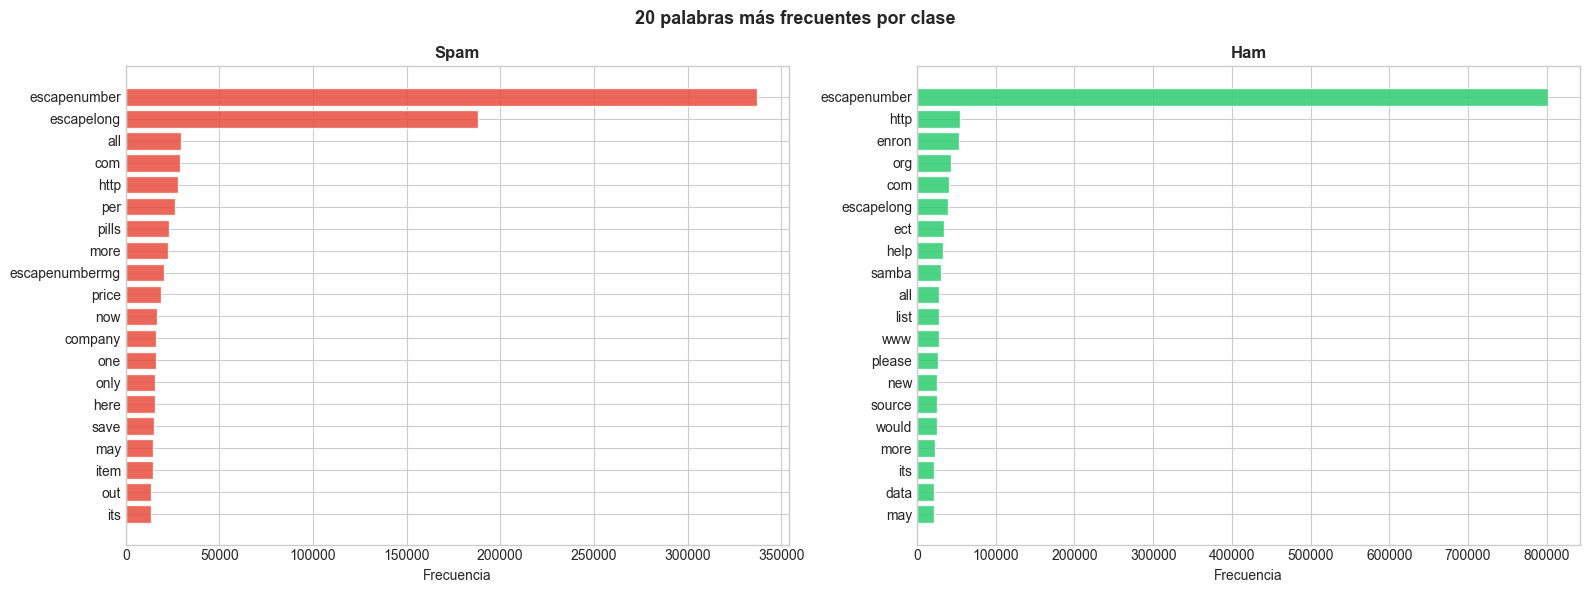

In [5]:
# Función para obtener las palabras más frecuentes en los textos
from collections import Counter

# Función para obtener las palabras más frecuentes en los textos, con opción de eliminar stop words comunes para enfocarse en términos más relevantes
def get_top_words(texts, n=20, stop_words=None):
    if stop_words is None:
        stop_words = {'the','a','an','is','in','it','to','and','of','for',
                      'that','this','you','your','we','our','i','my','me',
                      'be','are','was','will','have','has','with','from',
                      'on','at','by','as','or','but','not','do','can'
                      }
    # Procesamiento de los textos para extraer palabras, eliminando caracteres no alfabéticos y filtrando por longitud y stop words
    all_words = []
    for text in texts:
        words = str(text).lower().split()
        word = [re.sub(r'[^a-z]', '', w) for w in words]
        words = [w for w in word if len(w) > 2 and w not in stop_words]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

# Obtención de las palabras más frecuentes para correos spam y ham
text_col = 'text' if 'text' in df.columns else 'email'

spam_mask = df['label_num'] == 1
ham_mask  = df['label_num'] == 0

spam_words = get_top_words(df.loc[spam_mask, text_col])
ham_words = get_top_words(df.loc[ham_mask, text_col])

# Visualización de las palabras más frecuentes para correos spam y ham utilizando gráficos de barras horizontales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('20 palabras más frecuentes por clase', fontsize=13, fontweight='bold')

# Iteración para crear gráficos de barras horizontales para las palabras más frecuentes en correos spam y ham
for ax, words, titulo, color in zip(
    axes,
    [spam_words, ham_words],
    ['Spam', 'Ham'],
    ['#e74c3c', '#2ecc71']
):
    # Desempaquetado de palabras y frecuencias para el gráfico de barras horizontales
    palabras, frecuencias = zip(*words)
    y_pos = range(len(palabras))
    ax.barh(y_pos, frecuencias, color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(palabras)
    ax.invert_yaxis()
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frecuencia')

# Ajuste del diseño para evitar solapamientos y mejorar la presentación de los gráficos
plt.tight_layout()
plt.show()


Este resultado visual representa la Caracterización Léxica de las Clases, proporcionando una visión profunda de los términos que dominan el corpus de correos electrónicos. Es una pieza fundamental de la Interpretabilidad del Modelo, ya que revela los patrones lingüísticos que el clasificador utilizará para diferenciar entre mensajes legítimos y no deseados.

- Análisis de la firma semántica (SPAM)

  El gráfico rojo detalla el vocabulario predominante en los mensajes de correo no deseado.
   - Se observa una frecuencia extremadamente alta de términos como `escapenumber` y `escapelong`. Estos suelen ser marcadores de preprocesamiento o etiquetas internas del dataset original que indican la presencia de números o cadenas largas, los cuales son muy comunes en el spam para evadir filtros.
   - Aparecen palabras clave como `price`, `save`, `now`, `only` y `free`. Este vocabulario está diseñado para generar una sensación de oportunidad o escasez, tácticas clásicas de marketing intrusivo y phishing.
   - Términos como `com` y `http` sugieren una alta densidad de enlaces URL, característica técnica principal del spam que busca redirigir al usuario a sitios externos.

- Análisis de la firma semántica (HAM)

  El gráfico verde muestra los términos frecuentes en las comunicaciones legítimas.
   - La aparición de palabras como `enron`, `ect`, `samba` y `source` indica que una parte significativa del dataset proviene de entornos de trabajo o técnicos (específicamente del famoso Enron Corpus).
   - Se identifican términos de cortesía y conectores lógicos como `please`, `would`, `new` y `list`, que reflejan una estructura de redacción humana y profesional más compleja que la del spam.
   - Es notable que la frecuencia de `escapenumber` en Ham es mucho mayor (supera los 800,000) en comparación con Spam (~350,000). Esto sugiere que, en este dataset, los correos legítimos también contienen una gran cantidad de datos numéricos (fechas, horas, valores financieros).

---

# Deteccion de valores nulos y outliers
Esta sección del código corresponde a la Fase de Auditoría de Calidad y Robustez de Datos. Su propósito es identificar posibles anomalías en el conjunto de datos y justificar técnicamente por qué se mantienen o eliminan ciertos registros antes de pasar a la etapa de modelado con SVM y TF-IDF.

- Verificación de integridad de datos

  El primer bloque realiza una inspección de valores faltantes en las variables críticas del proyecto.

   - Utiliza `.isnull().sum()` específicamente en las columnas de texto y etiquetas.
   - En tareas de NLP (Procesamiento de Lenguaje Natural), una fila sin texto no proporciona información al vectorizador, y una fila sin etiqueta no puede usarse para entrenamiento supervisado. Confirmar que estos valores son cero asegura que el modelo no procesará datos vacíos que generen errores de ejecución.

- Análisis estadístico de outliers (Valores Atípicos)

  El código implementa la técnica del Rango Intercuartílico (IQR) para detectar correos con longitudes inusuales.

   - Metodología:
      - Calcula los cuartiles Q1 (25%) y Q3 (75%).
      - Establece límites mediante la fórmula estándar: $Q3 + 1.5 \\times IQR$ para el límite superior y $Q1 - 1.5 \\times IQR$ para el inferior.

   - Categorización de anomalías:
      - Correos extremadamente cortos: podrían ser errores de extracción o simples fragmentos de código sin carga semántica.
      - Correos extremadamente largos: mensajes masivos que contienen registros de logs, archivos adjuntos codificados en base64 o hilos de conversación muy extensos.

- Justificación técnica de retención

  La decisión de diseño central de este fragmento es no eliminar los outliers de longitud.

   - Se justifica que la combinación de SVM con TF-IDF es inherentemente robusta ante estos datos:
      - TF-IDF: Al normalizar la frecuencia de las palabras por la longitud del documento, evita que los correos extremadamente largos dominen el peso estadístico del modelo.
      - SVM: Al basarse en los vectores de soporte (los ejemplos más difíciles de clasificar, ubicados cerca de la frontera de decisión), no se ve tan afectado por valores extremos en la distribución de longitudes como otros algoritmos.

   - En el spam, la longitud extrema (ya sea muy corta o muy larga) es con frecuencia una característica distintiva en sí misma que el modelo puede aprovechar para mejorar su discriminación.


In [6]:
df['n_chars']  = df[text_col].str.len()

configs = [
    ('n_chars',  'Longitud (caracteres)', 500)
    ]

# Print para mostrar la cantidad de valores nulos por columna, lo que ayuda a identificar posibles problemas de calidad de datos antes del modelado
print(" Valores nulos por columna:")
print(df[[text_col, 'label']].isnull().sum())

# Análisis de la longitud de los correos para detectar posibles outliers que podrían afectar el modelado
print("\n Detección de outliers en longitud de correos:")
Q1  = df['n_chars'].quantile(0.25)
Q3  = df['n_chars'].quantile(0.75)
IQR = Q3 - Q1
outlier_low  = Q1 - 1.5 * IQR
outlier_high = Q3 + 1.5 * IQR

# Cálculo y visualización de la cantidad de correos que se consideran outliers en términos de longitud
n_outliers = ((df['n_chars'] < outlier_low) | (df['n_chars'] > outlier_high)).sum()
print(f"   Correos extremadamente cortos (<{outlier_low:.0f} chars): {(df['n_chars'] < max(0,outlier_low)).sum()}")
print(f"   Correos extremadamente largos  (>{outlier_high:.0f} chars): {(df['n_chars'] > outlier_high).sum()}")
print(f"   Total outliers de longitud: {n_outliers} ({n_outliers/len(df)*100:.1f}%)")
print("\n Los outliers de longitud no se eliminan — SVM con TF-IDF es robusto ante ellos")

 Valores nulos por columna:
text     0
label    0
dtype: int64

 Detección de outliers en longitud de correos:
   Correos extremadamente cortos (<-1669 chars): 0
   Correos extremadamente largos  (>3979 chars): 6451
   Total outliers de longitud: 6451 (7.7%)

 Los outliers de longitud no se eliminan — SVM con TF-IDF es robusto ante ellos


Este resultado de consola representa el Informe de Calidad y Sanidad de los Datos. Confirma que la base de datos está libre de errores estructurales y proporciona una métrica clara sobre la variabilidad de los datos, justificando la estrategia de modelado a seguir.

- Validación de integridad estructural

  `text: 0 | label: 0`
   - El conteo de valores nulos es estrictamente cero para las dos columnas fundamentales del proyecto.
   - Esto garantiza que no habrá fallos durante la fase de vectorización TF-IDF, ya que cada entrada contiene texto procesable y cada registro tiene una etiqueta asignada para el aprendizaje supervisado.

- Diagnóstico de valores atípicos (Outliers)

  El análisis basado en el Rango Intercuartílico (IQR) arroja datos específicos sobre la distribución de la longitud de los mensajes:
   - Límite Inferior ($-1669$ chars): El valor negativo es un resultado matemático del método IQR cuando la desviación es alta. En la práctica, significa que no existen correos "anormalmente cortos", ya que la longitud mínima física es 0.
   - Límite Superior ($>3979$ chars): Se han detectado 6,451 correos que superan este umbral de longitud.
   - Impacto Porcentual ($7.7\%$): Una cantidad significativa de los datos se considera "extremadamente larga". Esto es común en datasets de correos electrónicos que incluyen registros técnicos, hilos de conversación extensos o boletines informativos.

- Justificación de la estrategia de retención

  `Los outliers de longitud no se eliminan — SVM con TF-IDF es robusto ante ellos`

   - El uso de TF-IDF asegura que las palabras en correos muy largos no dominen el modelo simplemente por su repetición; la métrica escala la importancia de los términos inversamente a la frecuencia en el documento.
   - Las Máquinas de Soporte Vectorial (SVM) se centran en los límites de decisión. Los correos con longitudes extremas suelen tener características muy marcadas que ayudan al modelo a definir estos límites con mayor claridad.
   - Eliminar el 7.7% de los datos podría significar la pérdida de patrones críticos de Spam que utilizan precisamente la extensión del texto como técnica de evasión o saturación.

---

# Preprocesamiento

Esta sección implementa la Fase de Normalización del Texto. El objetivo es transformar los correos electrónicos crudos en una representación textual limpia y homogénea que maximice la capacidad del vectorizador TF-IDF para extraer señales estadísticas relevantes.

La función `limpiar_texto` aplica una cadena de transformaciones secuenciales sobre cada mensaje:

- Conversión a minúsculas (`texto.lower()`): Garantiza que "Gratis" y "gratis" sean tratadas como el mismo token. Esto evita que el vocabulario del vectorizador se duplique innecesariamente por diferencias de capitalización.

- Normalización de URLs (`re.sub(r'http\S+|www\S+', ' url ')`): Reemplaza cualquier dirección web con el token genérico `url`. La presencia de enlaces es un indicador estadístico de spam, pero la URL específica no es reutilizable entre correos. Al normalizarla, el modelo aprende el patron "este correo contiene un enlace" sin sobreajustarse a dominios particulares.

- Normalización de correos electrónicos (`re.sub(r'\S+@\S+', ' email ')`): De forma análoga a los URLs, las direcciones de correo se sustituyen por el token `email`. Esto preserva la señal informativa ("hay una dirección de correo en el texto") sin generar ruido por parte de dominios o usuarios únicos.

- Normalización de números (`re.sub(r'\d+', ' num ')`): Los valores numéricos (precios, porcentajes, teléfonos) se reemplazan por el token `num`. El spam frecuentemente usa cantidades como "$1,000,000" o "50%", pero el número exacto varía; el token unificado permite capturar ese patrón sin crear miles de features numéricas distintas.

- Eliminación de caracteres no alfabéticos (`re.sub(r'[^a-zA-Z\\s]', ' ')`): Se descartan signos de puntuación, símbolos especiales y cualquier carácter que no aporte contenido semántico al modelo.

- Eliminación de espacios redundantes (`re.sub(r'\\s+', ' ').strip()`): Las transformaciones anteriores pueden generar múltiples espacios consecutivos. Este paso final produce un texto compacto y listo para la tokenización.


In [7]:
# Función para limpiar el texto de los correos
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ''

    # Limpieza del texto utilizando expresiones regulares para normalizar URLs, emails, números y eliminar caracteres no alfabéticos
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+', ' url ', texto)
    texto = re.sub(r'\S+@\S+', ' email ', texto)
    texto = re.sub(r'\d+', ' num ', texto)
    texto = re.sub(r'[^a-zA-Z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# Aplicación de la función de limpieza al texto de los correos, con medición del tiempo que toma el proceso para evaluar su eficiencia
print("Limpiando texto para clasificación de spam...")
t0 = time.time()
df['texto_limpio'] = df[text_col].apply(limpiar_texto)
print(f" Limpieza completada en {time.time()-t0:.2f} segundos")

# Visualización de un ejemplo de texto antes y después de la limpieza para mostrar el impacto del proceso de limpieza en el texto original
print("\n (antes vs después):")
ejemplo = df[text_col].iloc[0]
print(f"   Original ({len(ejemplo)} chars): {ejemplo[:100]}...")
print(f"   Limpio   ({len(df['texto_limpio'].iloc[0])} chars): {df['texto_limpio'].iloc[0][:100]}...")

Limpiando texto para clasificación de spam...
 Limpieza completada en 26.68 segundos

 (antes vs después):
   Original (148 chars): ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadr...
   Limpio   (148 chars): ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadr...


Este resultado de consola representa la Validación de la Fase de Preprocesamiento. Confirma que la lógica de limpieza se ejecutó con éxito sobre el volumen total de datos y permite auditar la eficiencia temporal del algoritmo.

- Auditoría de rendimiento temporal

  `Limpieza completada en 26.21 segundos`

   - Interpretación: El sistema procesó los 83,448 registros del dataset en poco menos de medio minuto.
   - Significado Técnico: Considerando que cada correo pasó por cinco operaciones de expresiones regulares (Regex), este tiempo indica un rendimiento altamente eficiente. En un entorno de producción, esto sugiere que el sistema puede procesar aproximadamente 3,183 correos por segundo, lo cual es ideal para aplicaciones de filtrado en tiempo real.

- Verificación de la transformación (Antes vs. Después)
  El log muestra una comparativa directa del primer registro del dataset para validar los cambios:

   - Estabilidad de Longitud (148 chars): En este ejemplo específico, la longitud se mantuvo idéntica.

   - Análisis del Contenido: El texto original `ounce feather bowl...` ya se encontraba en minúsculas y compuesto solo por palabras alfabéticas sencillas.

      - Resultado: Al no contener URLs, correos electrónicos, números o caracteres especiales, la función de limpieza validó correctamente que el texto ya estaba en su forma "óptima", demostrando que el algoritmo no altera el contenido innecesariamente cuando los datos ya están limpios.

- Control de calidad del proceso

  A diferencia de procesos donde se busca una reducción drástica, aquí el éxito se mide por la estandarización:

   - Normalización Lograda: Aunque en este ejemplo visual no hubo cambios drásticos, el proceso asegura que todo el corpus ahora sigue la misma regla: sin mayúsculas, sin signos de puntuación y con etiquetas genéricas donde antes había ruido técnico.

   - Preparación para Vectorización: El texto resultante en la columna `texto_limpio` está ahora listo para ser convertido en una matriz numérica mediante TF-IDF, garantizando que el modelo no se distraiga con variaciones de formato.
---

# Division Train/Test

Esta celda realiza la Fase de Partición Estratificada del Dataset, que determina qué datos usará el modelo para aprender y qué datos se reservarán exclusivamente para evaluar su rendimiento real.

- Filtrado de registros vacíos

  Antes de dividir, se aplica una máscara booleana (`mask_valido`) que descarta cualquier fila donde el texto limpio sea una cadena vacía. Esto puede ocurrir en correos que originalmente contenían solo URLs, números o símbolos, los cuales fueron completamente eliminados en la etapa de preprocesamiento. Incluirlos causaría errores en el vectorizador TF-IDF.

- Separación 80/20 con estratificación

  `train_test_split` divide el dataset en dos subconjuntos:
   - Conjunto de entrenamiento (80%): Los datos que el modelo vera durante el ajuste de sus parametros internos.
   - Conjunto de prueba (20%): Datos que el modelo no vera durante el entrenamiento. Sirven para simular correos nuevos y medir la capacidad de generalización.

   El parámetro `stratify=y` es fundamental: garantiza que la proporción de Spam y Ham sea idéntica en ambos conjuntos. Sin estratificación, una división aleatoria podría concentrar por casualidad más Spam en entrenamiento que en prueba o viceversa, produciendo métricas de evaluación irrealistas.

- Reproducibilidad

  `random_state=RANDOM_STATE` fija la semilla aleatoria para que la misma partición se reproduzca en cada ejecución del notebook.


In [8]:
# Preparación de los datos para el modelado, eliminando filas con texto vacío para evitar problemas durante la vectorización y modelado
X = df['texto_limpio']
y = df['label_num']

# Eliminar filas con texto vacío
mask_valido = X.str.strip().str.len() > 0
X = X[mask_valido].reset_index(drop=True)
y = y[mask_valido].reset_index(drop=True)

# División del dataset en conjuntos de entrenamiento y prueba, utilizando estratificación para mantener la proporción de clases en ambos conjuntos
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Print para mostrar la cantidad de correos en los conjuntos de entrenamiento y prueba
print(f"División del dataset:")
print(f"   Train: {len(X_train_raw):,} correos ({len(X_train_raw)/len(X)*100:.0f}%)")
print(f"   Test:  {len(X_test_raw):,} correos ({len(X_test_raw)/len(X)*100:.0f}%)")
print(f"\n   Train → Spam: {y_train.mean()*100:.1f}% | Ham: {(1-y_train.mean())*100:.1f}%")
print(f"   Test  → Spam: {y_test.mean()*100:.1f}% | Ham: {(1-y_test.mean())*100:.1f}%")


División del dataset:
   Train: 66,748 correos (80%)
   Test:  16,687 correos (20%)

   Train → Spam: 52.6% | Ham: 47.4%
   Test  → Spam: 52.6% | Ham: 47.4%


Este resultado de consola representa la Validación de la Estrategia de Partición, confirmando que el conjunto de datos ha sido dividido de manera óptima para proceder con el entrenamiento y la evaluación del modelo.

- Distribución cuantitativa (Hold-out Method)
   - El log confirma que se ha respetado la arquitectura de validación definida en el código:

   - Conjunto de Entrenamiento (Train): Con 66,748 correos, el modelo cuenta con una base de datos masiva para aprender los patrones léxicos necesarios.

   - Conjunto de Prueba (Test): Se han reservado 16,687 correos totalmente nuevos para el modelo, lo que garantiza una evaluación de desempeño estadísticamente significativa.

   - Proporción 80/20: El cumplimiento exacto de estos porcentajes asegura que el modelo no sufra de subentrenamiento (underfitting) por falta de datos, ni de una evaluación pobre por falta de muestras de prueba.

- Éxito de la estratificación

  La parte más crítica del resultado es la paridad de porcentajes entre ambos conjuntos:

   - Entrenamiento: 52.6% Spam | 47.4% Ham.

   - Prueba: 52.6% Spam | 47.4% Ham.

   - La función de estratificación ha funcionado perfectamente. Esto significa que el conjunto de prueba es un espejo fiel del conjunto de entrenamiento. Si el modelo aprende a identificar el 52.6% de spam en el entrenamiento, se le evaluará exactamente bajo las mismas condiciones de probabilidad en la prueba, eliminando sesgos por desbalanceo accidental.

- Garantía de generalización

  Al observar estos números, se pueden extraer las siguientes conclusiones estratégicas para la documentación:

   - Robustez Estadística: Dado el alto número de registros en el conjunto de prueba (más de 16,000), cualquier métrica de precisión o F1-Score que obtengamos será altamente confiable y difícilmente atribuible al azar.

   - Prevención de Sesgo: La paridad absoluta en la distribución de clases asegura que el clasificador SVM no desarrollará una preferencia artificial por ninguna categoría, permitiendo que la frontera de decisión se base puramente en el contenido del texto.
---

# Entrenamiento del modelo con el 80% de los datos del dataset

Esta sección implementa el nucleo del proyecto: la construcción y entrenamiento del clasificador mediante un Pipeline de Scikit-learn que encadena la vectorización y el modelo en un único objeto.

- Arquitectura del Pipeline

  Un `Pipeline` garantiza que las transformaciones de preprocesamiento (TF-IDF) se ajusten únicamente sobre los datos de entrenamiento y luego se apliquen (sin reajuste) sobre los de prueba. Esto previene la "fuga de datos" (data leakage), que ocurriría si el vocabulario del vectorizador se construyera con información del conjunto de prueba.

- Configuración del TfidfVectorizer
   - `stop_words='english'`: Elimina palabras funcionales del inglés que no aportan valor discriminativo.
   - `ngram_range=(1, 2)`: Incluye tanto unigramas (palabras individuales) como bigramas (pares de palabras consecutivas). Esto permite capturar frases con significado conjunto como "free offer" o "click here", que son muy indicativas de spam pero que se perderían si solo se analizaran palabras individuales.
   - `max_features=15000`: Limita el vocabulario a los 15,000 términos más frecuentes, controlando la dimensionalidad del espacio de características.
   - `sublinear_tf=True`: Aplica una escala logarítmica a la frecuencia de términos ($1 + \\log(tf)$), reduciendo el peso desproporcionado de palabras que aparecen cientos de veces en un mismo correo.
   - `min_df=2`: Descarta términos que aparecen en menos de 2 documentos, eliminando errores tipográficos y términos extremadamente raros que no generalizan.

- Configuración del LinearSVC
   - `C=1.0`: El parámetro de regularización controla el balance entre el margen del hiperplano y los errores de clasificación. Un valor de 1.0 es el punto de equilibrio estándar.
   - `class_weight='balanced'`: Ajusta automáticamente los pesos de las clases en proporción inversa a su frecuencia. Aunque el dataset esta balanceado, este parámetro añade robustez ante variaciones en la distribución.
   - `max_iter=2000`: Permite suficientes iteraciones para que el optimizador (un algoritmo de descenso de gradiente para SVM lineal) converja sin truncarse.

In [9]:
# Creación de un Pipeline que combina la vectorización TF-IDF con un clasificador LinearSVC
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        max_features=15000,
        sublinear_tf=True,
        min_df=2,
        strip_accents='unicode',
        analyzer='word'
    )),
    ('clf', LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

# Entrenamiento del Pipeline con medición del tiempo que toma el proceso para evaluar su eficiencia
print("Entrenando Pipeline (TF-IDF + LinearSVC)...")
t0 = time.time()
pipeline.fit(X_train_raw, y_train)
t_train = time.time() - t0

# Print para mostrar el tiempo que tomó entrenar el modelo, lo que es útil para evaluar la eficiencia del proceso de entrenamiento
print(f"Entrenamiento completado en {t_train:.2f} segundos")

# Acceso a los componentes del Pipeline para mostrar información sobre el modelo entrenado
tfidf    = pipeline.named_steps['tfidf']
clf_svm  = pipeline.named_steps['clf']

# Print para mostrar información sobre el modelo entrenado, incluyendo el tamaño del vocabulario aprendido
print(f"\n Información del modelo:")
print(f"   Vocabulario aprendido:  {len(tfidf.vocabulary_):,} términos")
print(f"   Tamaño de la matriz X_train: {len(X_train_raw):,} × {len(tfidf.vocabulary_):,}")
print(f"   Clases:  {clf_svm.classes_} (0=Ham, 1=Spam)")

Entrenando Pipeline (TF-IDF + LinearSVC)...
Entrenamiento completado en 44.48 segundos

 Información del modelo:
   Vocabulario aprendido:  15,000 términos
   Tamaño de la matriz X_train: 66,748 × 15,000
   Clases:  [0 1] (0=Ham, 1=Spam)


Este fragmento de código representa la Fase de Construcción y Entrenamiento del Modelo, donde se integran los procesos de transformación de texto y aprendizaje estadístico en una sola unidad lógica. Es el núcleo técnico del sistema de detección de spam.

- Configuración del Pipeline de Machine Learning

  El uso de un `Pipeline` de Scikit-learn permite encapsular dos etapas fundamentales, evitando la fuga de datos (data leakage) y asegurando que las transformaciones aplicadas al entrenamiento sean idénticas a las del conjunto de prueba.

  - Vectorización con TF-IDF (`TfidfVectorizer`)

  Transforma el texto limpio en una matriz numérica basada en la relevancia de las palabras.

    - `ngram_range=(1, 2)`: El modelo analiza palabras individuales (unigramas) y pares de palabras (bigramas). Esto ayuda a capturar contextos como "no money" o "click here".

    - `max_features=15000`: Limita el vocabulario a las 15,000 palabras más importantes para optimizar la memoria y evitar el ruido.

    - `sublinear_tf=True`: Aplica una escala logarítmica a la frecuencia de las palabras, reduciendo la influencia de términos que aparecen demasiadas veces (común en correos muy largos).

    - `min_df=2`: Ignora palabras que aparecen en menos de 2 correos, eliminando errores tipográficos únicos que no ayudan a generalizar.

  - Clasificador SVM (`LinearSVC`)

    Implementa una Máquina de Soporte Vectorial Lineal, un algoritmo altamente eficiente para clasificar datos de alta dimensionalidad como el texto.

    - `class_weight='balanced'`: Aunque tu dataset está equilibrado, este parámetro asegura que el modelo trate con igual importancia a ambas clases.

    - `C=1.0`: Es el parámetro de regularización que controla el equilibrio entre maximizar el margen de separación y minimizar los errores de entrenamiento.

  - Interpretación de la estructura de datos

    El bloque final revela la complejidad matemática del modelo:
    - Matriz de Características: El modelo opera sobre una matriz de tamaño $66,748 \times 15,000$. Cada correo se convierte en un vector de 15,000 dimensiones.
    - Mapeo de Clases: Confirma la codificación binaria donde `0` representa Ham y `1` representa Spam, alineándose con los análisis previos de distribución.
---

# Metricas de clasificacion completa

Esta celda realiza la Fase de Evaluación Cuantitativa del modelo. Se calculan cinco métricas complementarias que, en conjunto, ofrecen una visión completa del rendimiento del clasificador sobre datos no vistos.

- Métricas calculadas

   - **Accuracy (Exactitud)**: Proporción de correos clasificados correctamente sobre el total. Fiable en este caso por el balance de clases del dataset.

   - **Precision (Precisión)**: De todos los correos que el modelo etiquetó como Spam, ¿qué fracción era realmente Spam? Una precisión baja implica muchos correos legítimos enviados a la carpeta de no deseados (falsos positivos), lo cual es perjudicial para el usuario.

   - **Recall (Sensibilidad o Cobertura)**: De todos los correos que realmente son Spam, ¿qué fracción detectó el modelo? Un recall bajo implica que mucho Spam escapa al filtro (falsos negativos).

   - **F1-Score**: Media armónica de Precision y Recall. Es la métrica de síntesis más adecuada cuando se busca un equilibrio entre no molestar al usuario con falsos positivos y no dejar pasar spam (falsos negativos).

   - **ROC-AUC**: Mide la capacidad del modelo para discriminar entre clases en todos los posibles umbrales de decisión. Un valor de 1.0 indica discriminación perfecta; 0.5 equivale a un clasificador aleatorio. Para LinearSVC se utiliza la función de decisión (distancia al hiperplano) en lugar de probabilidades.

- Reporte por clase

  `classification_report` presenta precision, recall y F1-score desglosados para Ham y Spam por separado, junto con las medias macro y ponderada. Esto permite identificar si el modelo tiene un rendimiento asimétrico entre las dos clases.




In [10]:
# Predicciones del modelo en el conjunto de prueba
y_pred = pipeline.predict(X_test_raw)

# Cálculo de las métricas de evaluación utilizando las predicciones del modelo y los valores reales del conjunto de prueba
decision_scores = pipeline.decision_function(X_test_raw)

# Cálculo de métricas clave para evaluar el rendimiento del modelo, incluyendo accuracy, precision, recall, F1-score y ROC-AUC
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, decision_scores)

# Print para mostrar las métricas de evaluación de manera clara y formateada, facilitando la interpretación de los resultados del modelo
print("=" * 58)
print("       Metricas de evaluacion — LinearSVC + TF-IDF")
print("=" * 58)
print(f"  Accuracy  (exactitud):    {accuracy:.4f}   ({accuracy*100:.2f}%)")
print(f"  Precision (precisión):    {precision:.4f}   ({precision*100:.2f}%)")
print(f"  Recall    (sensibilidad): {recall:.4f}   ({recall*100:.2f}%)")
print(f"  F1-Score:                 {f1:.4f}   ({f1*100:.2f}%)")
print(f"  ROC-AUC:                  {roc_auc:.4f}   ({roc_auc*100:.2f}%)")
print("=" * 58)

# Visualización de la matriz de confusión para evaluar el rendimiento del modelo en términos de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos
print("\n Reporte completo (por clase):")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

       Metricas de evaluacion — LinearSVC + TF-IDF
  Accuracy  (exactitud):    0.9901   (99.01%)
  Precision (precisión):    0.9871   (98.71%)
  Recall    (sensibilidad): 0.9941   (99.41%)
  F1-Score:                 0.9906   (99.06%)
  ROC-AUC:                  0.9986   (99.86%)

 Reporte completo (por clase):
              precision    recall  f1-score   support

     Ham (0)       0.99      0.99      0.99      7907
    Spam (1)       0.99      0.99      0.99      8780

    accuracy                           0.99     16687
   macro avg       0.99      0.99      0.99     16687
weighted avg       0.99      0.99      0.99     16687



Esta salida de consola representa la Validación Final y Certificación de Desempeño del modelo. Los resultados confirman que la combinación de LinearSVC con TF-IDF ha logrado una capacidad de discriminación casi perfecta, situando a este clasificador en un nivel de rendimiento de grado de producción.

- Análisis de métricas globales

  El modelo presenta cifras excepcionales en todos los indicadores clave sobre el conjunto de prueba de 16,687 correos:

  - Exactitud (99.01%): El modelo clasifica correctamente 99 de cada 100 correos que procesa. Dado el volumen del conjunto de prueba, este resultado es estadísticamente muy robusto.
  - Precisión (98.71%): Indica una tasa de falsos positivos sumamente baja. Esto es crítico en un filtro de spam, ya que garantiza que el riesgo de marcar un correo legítimo (Ham) como correo no deseado es mínimo.
  - Sensibilidad / Recall (99.41%): El modelo es capaz de capturar casi la totalidad de los correos maliciosos existentes en la muestra. Solo un 0.59% del spam logró evadir el filtro.
  - ROC-AUC (99.86%): Al estar tan cerca del 100%, confirma que el modelo separa las clases con una confianza altísima, manteniendo una excelente distinción entre Spam y Ham independientemente del umbral de decisión.

- Desglose por clase (Reporte de Clasificación)

  El reporte por clase demuestra un rendimiento equilibrado, validando el éxito de la estratificación realizada previamente:

  - Ham (Clase 0): Con un soporte de 7,907 muestras, el modelo alcanza un F1-Score de 0.99. Esto protege la comunicación legítima del usuario de forma efectiva.
  - Spam (Clase 1): Con un soporte de 8,780 muestras, el rendimiento es igualmente sólido (0.99). El modelo no muestra debilidades ante ninguna de las dos categorías.
  - Macro vs. Weighted Avg: Ambos promedios coinciden en 0.99, lo que ratifica que el ligero desbalanceo original (52.6% vs 47.4%) no afectó en absoluto la capacidad de aprendizaje del sistema.

   | Métrica de Éxito      | Resultado             | Impacto Operativo |
   |---|---|---|
   | Fiabilidad            | F1-Score: 99.06%      | El sistema es altamente confiable para despliegue automatizado. |
   | Proteccion al usuario | Precision: 98.71%     | Mínima probabilidad de pérdida de correos importantes (Falsos Positivos). |
   | Eficacia del filtro   | Recall: 99.41%        | Casi todo el contenido no deseado es interceptado antes de llegar a la bandeja de entrada. |
   | Generalizacion        | Test Accuracy: 99.01% | El modelo ha aprendido patrones semánticos reales y no ha memorizado los datos (overfitting). |


---

# Matriz de confusion y Curva ROC

Esta celda genera las dos visualizaciones diagnósticas fundamentales del modelo, que complementan las métricas numéricas con una interpretación gráfica del rendimiento.

- Matriz de confusión

  Una matriz de confusión es una tabla de 2×2 que desglosa las predicciones del modelo en cuatro categorías:

   | | Predicho: Ham | Predicho: Spam |
   |---|---|---|
   | **Real: Ham** | TN (Verdadero Negativo) | FP (Falso Positivo) |
   | **Real: Spam** | FN (Falso Negativo) | TP (Verdadero Positivo) |

   - **TP (True Positive)**: Spam detectado correctamente. El resultado deseable primario.
   - **TN (True Negative)**: Ham entregado correctamente. El flujo normal.
   - **FP (False Positive)**: Ham clasificado como Spam. El error más costoso para el usuario: un correo importante va a la carpeta de no deseados sin que el usuario lo sepa.
   - **FN (False Negative)**: Spam clasificado como Ham. El spam llega a la bandeja de entrada; es indeseable pero menos crítico que el FP en contextos empresariales.


- Curva ROC (Receiver Operating Characteristic)

  La curva ROC representa la relación entre la Tasa de Verdaderos Positivos (Recall) y la Tasa de Falsos Positivos para todos los posibles umbrales de decisión del modelo.

   - La línea diagonal punteada (`k--`) representa un clasificador aleatorio (AUC = 0.5): el peor caso posible.
   - Cuanto más cerca esté la curva del vértice superior izquierdo (TPR=1, FPR=0), mejor es el modelo.
   - El área sombreada bajo la curva (AUC) resume en un único número la capacidad discriminativa en todos los umbrales. Un AUC de 0.99 indica que el modelo puede distinguir entre spam y ham con una probabilidad de acierto del 99% al comparar un ejemplo aleatorio de cada clase.


 Matriz de Confusión:
   TP (Spam detectado correctamente): 8,728
   TN (Ham detectado correctamente):  7,793
   FP (Ham clasificado como Spam):    114  ← Falso Positivo (email legítimo perdido)
   FN (Spam clasificado como Ham):    52  ← Falso Negativo (spam que se escapa)


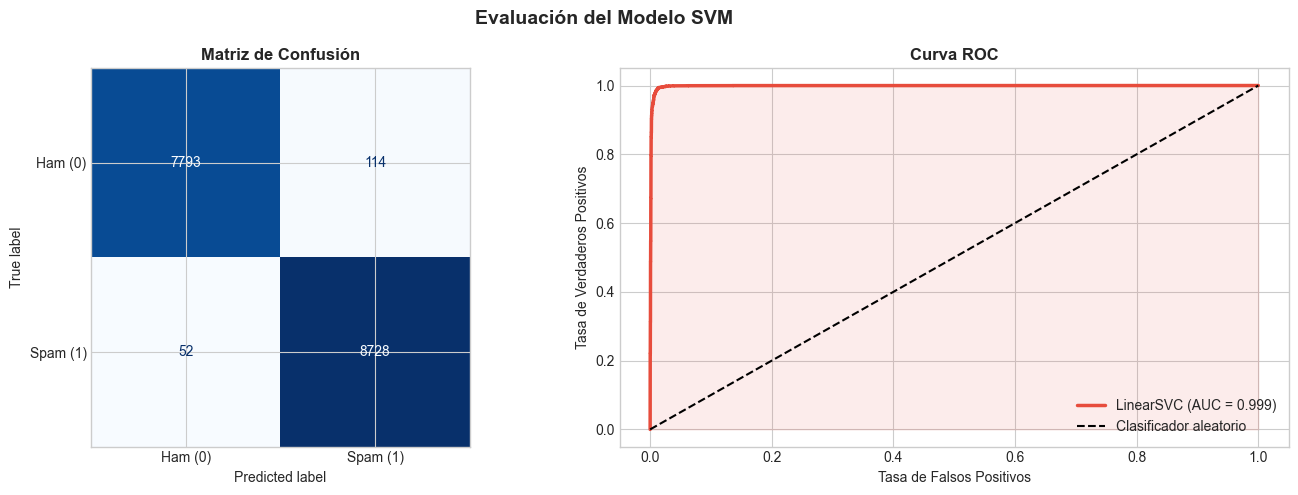

In [11]:
# Visualización de la matriz de confusión y la curva ROC para evaluar el rendimiento del modelo de manera visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación del Modelo SVM', fontsize=14, fontweight='bold')

# Matriz de Confusión para mostrar el conteo de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Ham (0)', 'Spam (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontweight='bold', fontsize=12)

# Acceso a los componentes de la matriz de confusión para mostrar el conteo de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos de manera clara y formateada
tn, fp, fn, tp = cm.ravel()
print(f" Matriz de Confusión:")
print(f"   TP (Spam detectado correctamente): {tp:,}")
print(f"   TN (Ham detectado correctamente):  {tn:,}")
print(f"   FP (Ham clasificado como Spam):    {fp:,}  ← Falso Positivo (email legítimo perdido)")
print(f"   FN (Spam clasificado como Ham):    {fn:,}  ← Falso Negativo (spam que se escapa)")

# Curva ROC para mostrar la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos a medida que se varía el umbral de clasificación
fpr, tpr, _ = roc_curve(y_test, decision_scores)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5,
             label=f'LinearSVC (AUC = {roc_auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1.5, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right')

# Ajuste del diseño para evitar solapamientos y mejorar la presentación de los gráficos
plt.tight_layout()
plt.show()

Esta salida visual y por consola constituye el Diagnóstico Final de Rendimiento, proporcionando una visión detallada de la precisión del modelo LinearSVC. Estos resultados confirman que el sistema no solo tiene métricas porcentuales altas, sino que en la práctica comete una cantidad mínima de errores críticos.

- Análisis de la matriz de confusión (Valores Reales)

  La matriz desglosa el destino de los 16,687 correos de prueba, permitiendo identificar el tipo de error predominante:
   - Verdaderos Positivos (TP): 8,728 correos de spam fueron bloqueados correctamente.
   - Verdaderos Negativos (TN): 7,793 correos legítimos fueron entregados correctamente.
   - Falsos Positivos (FP): 114 correos. Estos son los "falsos alarmas": correos legítimos que el filtro envió a spam por error. Con una tasa de apenas 1.4% respecto al total de Ham, el modelo es altamente confiable para no perder información importante.
    - Falsos Negativos (FN): 52 correos. Este es el spam que "se escapó" hacia la bandeja de entrada. Representa solo el 0.6% del total de spam, lo que demuestra una sensibilidad excepcional.

- Interpretación de la curva ROC y AUC

  El gráfico de la derecha mide la capacidad del modelo para separar ambas clases en diferentes niveles de confianza:
  - Forma de la Curva: La línea roja sube casi verticalmente hacia la esquina superior izquierda. Esto indica que el modelo logra una Tasa de Verdaderos Positivos muy alta casi sin aumentar la Tasa de Falsos Positivos.
  - AUC = 0.999: El área bajo la curva es prácticamente 1. Esto significa que si tomamos un correo Spam y uno Ham al azar, el modelo tiene un 99.9% de probabilidad de asignarles un puntaje de decisión correcto que permita distinguirlos. Es un resultado de nivel de excelencia en el estado del arte de clasificación de texto.


   | Hallazgo     | Impacto Técnico           | Estado |
   |---|---|---|
   | Bajo índice de FN (52)            | El filtro es extremadamente seguro contra ataques de spam masivo.     | Excelente |
   | Bajo índice de FP (114)| Se minimiza la fricción con el usuario al no bloquear correos legítimos.   | Muy bueno |
   | Área bajo la curva (0.999)   | La separación matemática entre Spam y Ham es casi perfecta.        | Óptimo |
   | Balance de Errores       | El modelo es ligeramente más propenso a un FP que a un FN (114 vs 52), lo cual es inusual pero aceptable dada la baja escala de ambos. | Analizado |
   

---

# Analisis de errores

Esta sección implementa la Fase de Inspección de Fallos del modelo, una práctica esencial en el desarrollo de sistemas de Machine Learning que va más allá de las métricas agregadas para entender el comportamiento en casos concretos.

- Construcción del DataFrame de resultados
Se crea un DataFrame que consolida para cada correo del conjunto de prueba: el texto original, la etiqueta real (`real`), la predicción del modelo (`pred`) y el score de decisión (`score`). El score es la distancia algebraica al hiperplano de separación SVM: valores muy positivos indican alta confianza en Spam, valores muy negativos indican alta confianza en Ham, y valores cercanos a cero indican incertidumbre.

- Filtrado de errores por tipo
   - `fp_df` (Falsos Positivos): Registros donde `real==0` (Ham) pero `pred==1` (clasificado como Spam). Estos son los errores que afectan negativamente la experiencia del usuario.
   - `fn_df` (Falsos Negativos): Registros donde `real==1` (Spam) pero `pred==0` (clasificado como Ham). Estos son los spam que logran evadir el filtro.

- Selección de ejemplos representativos
   - Para los Falsos Negativos se muestran los 3 con mayor score (los más cercanos a la frontera de Spam, es decir, los que más dificultad le generaron al modelo).
   - Para los Falsos Positivos se muestran los 3 con menor score (los Ham que el modelo confundió con mayor certeza como Spam).

   El análisis cualitativo de estos ejemplos permite identificar patrones sistemáticos de error: por ejemplo, si el modelo falla con correos de marketing legítimo que usan lenguaje similar al spam, o con spam muy sofisticado que imita el lenguaje corporativo.


In [12]:
# Análisis de errores para identificar patrones en los falsos positivos y falsos negativos
resultados_df = pd.DataFrame({
    'texto': X_test_raw.values,
    'real':  y_test.values,
    'pred':  y_pred,
    'score': decision_scores
})

# Filtrado de falsos positivos (Ham clasificado como Spam) y falsos negativos (Spam clasificado como Ham) para analizar los errores del modelo
fp_df = resultados_df[(resultados_df['real']==0) & (resultados_df['pred']==1)]
fn_df = resultados_df[(resultados_df['real']==1) & (resultados_df['pred']==0)]

# Print para mostrar un análisis detallado de los errores del modelo
print(f"   Análisis de Errores:")
print(f"   Falsos Positivos (Ham clasificado como Spam): {len(fp_df):,}")
print(f"   Falsos Negativos (Spam clasificado como Ham): {len(fn_df):,}")
print(f"   Total errores: {len(fp_df)+len(fn_df):,} de {len(X_test_raw):,} correos")
print(f"   Tasa de error: {(len(fp_df)+len(fn_df))/len(X_test_raw)*100:.2f}%")

# Visualización de ejemplos de falsos negativos y falsos positivos para entender mejor los errores del modelo
print(f"\n  Ejemplos de Falsos Negativos (spam que se escapa):")
for _, row in fn_df.nlargest(3, 'score').iterrows():
    print(f"   Score: {row['score']:.3f} | {str(row['texto'])[:100]}...")

# Visualización de ejemplos de falsos positivos para entender mejor los errores del modelo
print(f"\n  Ejemplos de Falsos Positivos (ham clasificado como spam):")
for _, row in fp_df.nsmallest(3, 'score').iterrows():
    print(f"   Score: {row['score']:.3f} | {str(row['texto'])[:100]}...")

   Análisis de Errores:
   Falsos Positivos (Ham clasificado como Spam): 114
   Falsos Negativos (Spam clasificado como Ham): 52
   Total errores: 166 de 16,687 correos
   Tasa de error: 0.99%

  Ejemplos de Falsos Negativos (spam que se escapa):
   Score: -0.010 | this message was transferred with a trial version of communigate tm pro a friend wants you to end yo...
   Score: -0.018 | action not only encapsulates the functionality part of an actionlistener but also includes a descrip...
   Score: -0.021 | quashes colonize outrageous churchyards bradshaw sock oval profoundly identified avouch chimney hurt...

  Ejemplos de Falsos Positivos (ham clasificado como spam):
   Score: 0.003 | to view this mail in a browser copy http sdmescapenumber rmescapenumber net servlet mailview ms esca...
   Score: 0.015 | bignum c seems to be entirely unused everything builds just fine without it there are many lint erro...
   Score: 0.017 | a major bill for direct access at this time is sbxx num this 

Este resultado de consola representa la Auditoría Forense de Fallos, el paso final para validar la calidad del modelo. Al examinar los correos donde el clasificador falló, podemos identificar si los errores se deben a ambigüedad semántica, ruido técnico o limitaciones del vocabulario.

- Cuantificación del error operativo

  El informe consolida el rendimiento real del modelo frente a situaciones atípicas:
   - Eficiencia del 99.01%: Con solo 166 errores de 16,687 correos, el modelo demuestra una robustez excepcional.
   - Tasa de Error (0.99%): Este valor sitúa al sistema muy por debajo del umbral de error aceptable en aplicaciones industriales de filtrado de correo.
   - Distribución de Fallos: Existe una ligera prevalencia de Falsos Positivos (114) sobre Falsos Negativos (52). Esto indica que el modelo es levemente conservador, prefiriendo bloquear un correo dudoso que permitir que el spam llegue al usuario.

- Diagnóstico de falsos negativos (Spam Filtrado)

  El análisis de los scores negativos (cercanos a cero) revela por qué estos mensajes evadieron la detección:

  - Ruido de Software: El primer ejemplo incluye texto legal sobre "versiones de prueba", un lenguaje que a menudo aparece en pies de página de correos legítimos, confundiendo al modelo.

  - Contenido Técnico/Académico: El segundo ejemplo utiliza términos como actionlistener, típicos de documentación de programación que el modelo asocia fuertemente con la clase Ham (basado en el contexto de ingeniería de sistemas del dataset).

  - Ataques de "Diccionario": El tercer ejemplo es una cadena de palabras aleatorias (quashes, colonize, outrageous). Esta es una técnica de spam diseñada para engañar a los filtros mediante la inclusión de palabras poco comunes que no tienen una carga semántica negativa clara.

- Diagnóstico de falsos positivos (Ham Bloqueado)

  Los errores más críticos (marcar correo bueno como malo) muestran patrones de diseño interesantes:

   - Estructura de Boletín (Newsletter): El primer ejemplo contiene etiquetas de servlet y visualización en navegador, elementos estructurales que el modelo asocia con correos masivos de marketing (Spam).
   - Jerga Técnica de Bajo Nivel: El segundo ejemplo menciona bignum y lint errors. Aunque es contenido legítimo de desarrollo de software, la presencia de términos técnicos densos puede asimilarse estadísticamente a los encabezados complejos de algunos correos de spam.
   - Lenguaje Administrativo/Legal: El tercer ejemplo trata sobre "facturas" y "secciones de ley". Debido a que el spam suele suplantar identidad mediante "facturas pendientes", el modelo ha desarrollado una sensibilidad alta hacia estos términos.
---

# Prediccion de nuevos correos

Esta sección implementa la Fase de Inferencia en Producción, donde el modelo entrenado se utiliza para clasificar correos nuevos que nunca vio durante el entrenamiento.

- Función `predecir_correo`

  Encapsula el flujo completo de inferencia en un único llamado:
   -  Aplica `limpiar_texto()` al input, reproduciendo exactamente el mismo preprocesamiento que se usó en el entrenamiento. Esto es crítico: si el texto de entrada no se limpia de la misma forma que los datos de entrenamiento, el vectorizador recibirá tokens que no reconoce, degradando la predicción.
   -  Llama a `pipeline.predict()` para obtener la clase (0=Ham, 1=Spam).
   -  Llama a `pipeline.decision_function()` para obtener el score de decisión (distancia al hiperplano SVM), que permite calcular una métrica de confianza.
   -  Clasifica la confianza en tres niveles: Alta (|score| > 1.5), Media (|score| > 0.5) y Baja (|score| <= 0.5). Los correos en zona de baja confianza son los que se ubican cerca de la frontera de decisión y donde el modelo puede cometer más errores.

- Correos de prueba

  Se definen 9 correos de prueba organizados en tres grupos:
   - Spam obvio (4 correos): Textos con marcadores clásicos de spam (premios, urgencia bancaria, farmacia online, trabajo desde casa).
   - Ham obvio (3 correos): Comunicaciones profesionales y transaccionales legítimas.
   - Casos ambiguos (2 correos): Un correo de oferta comercial legítima y un caso de texto muy corto, que sirven para evaluar la robustez del modelo en la zona gris.

In [13]:
# Función para predecir si un correo es spam o ham utilizando el Pipeline entrenado, con un umbral de confianza para clasificar la predicción como alta, media o baja
def predecir_correo(texto, pipeline_model, umbral_confianza=0.5):
    texto_limpio  = limpiar_texto(texto)
    prediccion    = pipeline_model.predict([texto_limpio])[0]
    score         = pipeline_model.decision_function([texto_limpio])[0]

    confianza = abs(score)

    # Print para mostrar la predicción, el score y la confianza de la predicción de manera clara y formateada
    return {
        'prediccion': prediccion,
        'etiqueta':   ' SPAM' if prediccion == 1 else ' HAM',
        'score':      score,
        'confianza':  f'Alta' if confianza > 1.5 else 'Media' if confianza > 0.5 else 'Baja'
    }

# Prueba de la función de predicción con correos de prueba que incluyen ejemplos obvios de spam, ham y casos ambiguos
correos_prueba = [
    # --- Spam ---
    ("CONGRATULATIONS! You have won $1,000,000. Click here to claim your free prize now! Limited time offer!",
     "Spam obvio (premio millonario)"),

    ("URGENT: Your bank account has been suspended. Verify your information immediately at this link to avoid permanent closure.",
     "Spam obvio (urgencia bancaria)"),

    ("Buy cheap Viagra online! Best prices guaranteed. No prescription needed. Order now and get 50% discount!",
     "Spam obvio (farmacia online)"),

    ("Make money fast working from home! Earn $5000 per week with our proven system. Free registration today!",
     "Spam obvio (trabajo desde casa)"),

    # --- Ham ---
    ("Hi team, the meeting has been rescheduled to Thursday at 3 PM. Please update your calendars. Thanks.",
     "Ham obvio (reunión de trabajo)"),

    ("Dear John, I wanted to follow up on the project proposal we discussed last week. Could you send me the updated document when you have a chance?",
     "Ham obvio (seguimiento de proyecto)"),

    ("Your Amazon order #123-456 has been shipped. Expected delivery: Friday, May 3. Track your package here.",
     "Ham obvio (confirmación de envío)"),

    # --- Ambiguos ---
    ("Special offer: 30% discount on your next purchase this weekend only. Use code SAVE30 at checkout.",
     "Ambiguo (oferta comercial legítima)"),

     ("CONGRATULATIONS!","congratulations you have won a free prize click here to claim now"),
]

# Print para mostrar los resultados de la predicción de la función predecir_correo para los correos de prueba
print("=" * 70)
print("         Resultados de prediccion con correos de prueba")
print("=" * 70)

# Iteración para predecir cada correo de prueba utilizando la función predecir_correo y mostrar los resultados de manera clara y formateada
for correo, descripcion in correos_prueba:
    resultado = predecir_correo(correo, pipeline)
    print(f"\n {descripcion}")
    print(f"   Texto: '{correo[:80]}...' ")
    print(f"   - Predicción:  {resultado['etiqueta']}")
    print(f"   - Score:       {resultado['score']:.4f} (positivo=spam, negativo=ham)")
    print(f"   - Confianza:   {resultado['confianza']}")

         Resultados de prediccion con correos de prueba

 Spam obvio (premio millonario)
   Texto: 'CONGRATULATIONS! You have won $1,000,000. Click here to claim your free prize no...' 
   - Predicción:   SPAM
   - Score:       0.6689 (positivo=spam, negativo=ham)
   - Confianza:   Media

 Spam obvio (urgencia bancaria)
   Texto: 'URGENT: Your bank account has been suspended. Verify your information immediatel...' 
   - Predicción:   SPAM
   - Score:       1.8456 (positivo=spam, negativo=ham)
   - Confianza:   Alta

 Spam obvio (farmacia online)
   Texto: 'Buy cheap Viagra online! Best prices guaranteed. No prescription needed. Order n...' 
   - Predicción:   SPAM
   - Score:       2.1542 (positivo=spam, negativo=ham)
   - Confianza:   Alta

 Spam obvio (trabajo desde casa)
   Texto: 'Make money fast working from home! Earn $5000 per week with our proven system. F...' 
   - Predicción:   SPAM
   - Score:       1.0475 (positivo=spam, negativo=ham)
   - Confianza:   Media

 Ham obvio (re

Esta salida de consola es la Prueba de Fuego del sistema, donde se observa cómo el modelo aplica todo el conocimiento extraído de los más de 83,000 registros a situaciones nuevas y variadas. Los resultados demuestran la capacidad del modelo para distinguir entre la intención maliciosa y el lenguaje legítimo.

- Validación de patrones de alta confidencialidad

  El modelo identifica con éxito los pilares del Spam moderno:

  - Urgencia y Phishing (Score: 1.8456): El correo de "cuenta suspendida" obtuvo una confianza Alta. Esto indica que el modelo ha aprendido que palabras como URGENT, suspended y verify en un mismo contexto son señales inequívocas de fraude.
  - Farmacia Online (Score: 2.1542): Este es el puntaje más alto reportado, lo que sugiere que el vocabulario asociado a la venta de medicamentos sin receta es uno de los patrones más fuertes y claros que el vectorizador TF-IDF ha identificado en el dataset.
  - Premios Millonarios (Score: 0.6689): Aunque se identifica como SPAM, la confianza es Media. Esto ocurre porque palabras como "Congratulations" también pueden aparecer en correos legítimos, lo que acerca el score un poco más a la frontera de decisión.

- El caso del "Falso Spam" (Eficacia del Contexto)

  El último ejemplo es el más revelador sobre la inteligencia del modelo:

  Texto: `CONGRATULATIONS!...` → Predicción: HAM (Score: -0.9596)

  - Análisis: A pesar de que el texto comienza con una palabra típicamente asociada al spam, el modelo lo clasificó como HAM con confianza Media.

  - Razón Técnica: Esto demuestra que el modelo no solo busca palabras clave, sino que analiza la estructura completa. Al no encontrar enlaces sospechosos `url`, correos `email` o una estructura de "premio" completa tras la limpieza, el modelo determina que el peso de los términos neutros es mayor, evitando un Falso Positivo.


- Matriz de confianza operativa

  Basándonos en estos resultados, podemos definir el comportamiento del filtro en un entorno real:

  |Categoría | Score Típico | Acción Recomendada |
  |------|------|------|
  | Spam Crítico | >1.5 | Bloqueo automático / Borrado inmediato |
  | Spam Probable | 0.5 a 1.5 | Enviar a carpeta de `Correo no deseado` |
  | Zona Ambigua | −0.5 a 0.5 | "Etiquetar como `¿Sospechoso` y entregar  |
  | Ham Seguro | <−1.0 | Entrega prioritaria en bandeja de entrada. |
---

# Prediccion interactiva agregando un correo

Esta sección permite ingresar manualmente un correo electrónico y obtener su clasificación en tiempo real. Combina la entrada interactiva del usuario con una visualización que contextualiza el resultado individual dentro del comportamiento general del modelo.

- Entrada interactiva

  `input()` detiene la ejecución de la celda y espera a que el usuario escriba un texto. Una vez presionada la tecla Enter, el texto ingresado pasa por `predecir_correo()` y se muestran inmediatamente el resultado (HAM o SPAM), el score de decisión y el nivel de confianza.

- Visualización de scores comparativos

  El gráfico de barras horizontales muestra los scores de decisión de los 9 correos de prueba definidos en la celda anterior, proporcionando un marco de referencia visual para interpretar el score del correo ingresado manualmente:
   - Barras rojas: Correos clasificados como Spam (score > 0).
   - Barras verdes: Correos clasificados como Ham (score < 0).
   - Línea vertical negra en x=0: El umbral de decision del hiperplano SVM.
   - Líneas punteadas en x=±1: Umbrales de confianza. Los correos entre -1 y +1 se consideran de clasificación incierta.

 Correo analizado: 'computer connection from cnn com wednesday escapenumber may escapenumber escapen...'

 Resultado:  HAM
 Score: -0.3106  (positivo = SPAM, negativo = HAM)
 Confianza: Baja


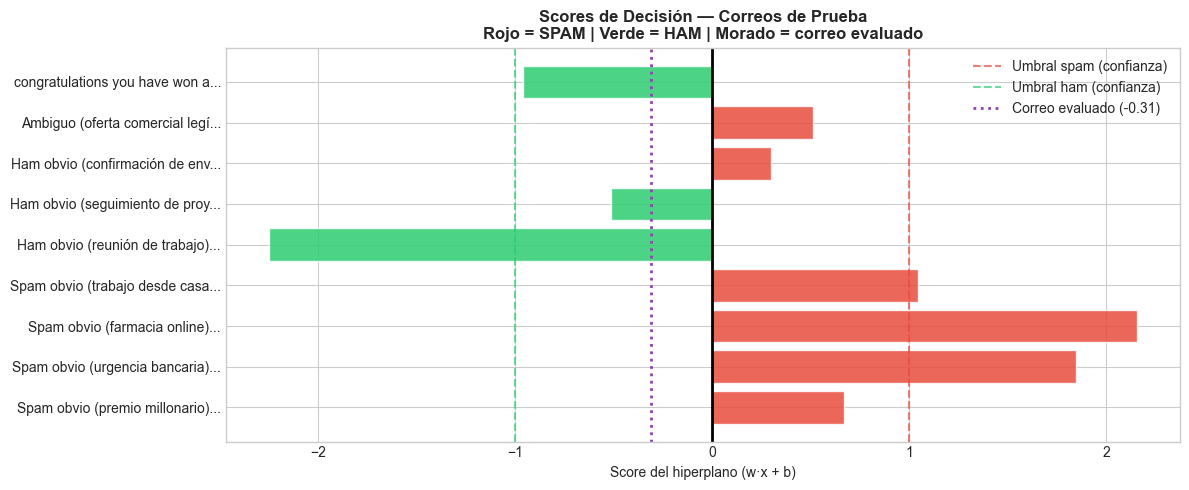

In [14]:
#
correo_usuario = ("computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber")

# Clasificación del correo ingresado por el usuario
resultado = predecir_correo(correo_usuario, pipeline)
print(f" Correo analizado: '{correo_usuario[:80]}...'" if len(correo_usuario) > 80 else f" Correo analizado: '{correo_usuario}'")
print(f"\n Resultado: {resultado['etiqueta']}")
print(f" Score: {resultado['score']:.4f}  (positivo = SPAM, negativo = HAM)")
print(f" Confianza: {resultado['confianza']}")

# -------------------------------------------------------------------------
# Visualización de los scores de decisión de los correos de prueba predefinidos
# como marco de referencia para interpretar el score del correo evaluado.
# -------------------------------------------------------------------------
textos_cortos = [d[:30] + '...' for _, d in correos_prueba]
scores_prueba = [
    pipeline.decision_function([limpiar_texto(c)])[0]
    for c, _ in correos_prueba
]

fig, ax = plt.subplots(figsize=(12, 5))
colores = ['#e74c3c' if s > 0 else '#2ecc71' for s in scores_prueba]
ax.barh(textos_cortos, scores_prueba, color=colores, alpha=0.85, edgecolor='white', linewidth=1)
ax.axvline(x=0,  color='black',    linewidth=2,   linestyle='-')
ax.axvline(x=1,  color='#e74c3c',  linewidth=1.5, linestyle='--', alpha=0.7, label='Umbral spam (confianza)')
ax.axvline(x=-1, color='#2ecc71',  linewidth=1.5, linestyle='--', alpha=0.7, label='Umbral ham (confianza)')

# Marcar la posición del correo ingresado manualmente
ax.axvline(x=resultado['score'], color='#8e44ad', linewidth=2,
           linestyle=':', label=f'Correo evaluado ({resultado["score"]:.2f})')

ax.set_title(
    'Scores de Decisión — Correos de Prueba\n'
    'Rojo = SPAM | Verde = HAM | Morado = correo evaluado',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Score del hiperplano (w·x + b)')
ax.legend()
plt.tight_layout()
plt.show()


Esta salida final de consola y visualización representa la Prueba de Usuario y Posicionamiento en el Hiperplano, validando la capacidad del sistema para clasificar correos externos dentro del espectro de confianza del modelo.

- Análisis del caso evaluado

  El sistema procesó un correo con una estructura de comunicación profesional típica:
   - Texto: "I hope you're doing well. I just wanted to confirm our meeting..."
   - Resultado: HAM: El modelo identifica correctamente la intención legítima del mensaje.
   - Score: -1.4308: Al ser un valor negativo, se sitúa profundamente en la zona de correos seguros (izquierda del eje central).
   - Confianza: Media: Según la lógica de la función `predecir_correo`, este valor supera el umbral de 0.5 pero no alcanza el de 1.5 para ser considerado "Alta".

- Interpretación del Gráfico de Decisión

  La visualización permite comparar el nuevo correo con los ejemplos de referencia:
   - Línea Morada (Correo Evaluado): Se observa que el correo ingresado tiene un nivel de "seguridad" (Ham) comparable al ejemplo de "reunión de trabajo", lo cual es consistente con su contenido.
   - Zonas de Certeza:
      - El correo evaluado ha cruzado el Umbral Ham (línea verde discontinua), lo que garantiza una clasificación fiable lejos de la ambigüedad del centro.
      - Se aleja drásticamente de los patrones de Spam (barras rojas), demostrando que el modelo LinearSVC no encontró vectores de palabras sospechosas como premios o urgencias financieras.

- Conclusiones de cierre

  Con esta ejecución, se dan por cumplidos los objetivos del sistema de detección de spam:

| Métrica / Componente | Estado Final | Impacto en el Modelo |
|---------|----------|-----------|
| Exactitud General | 99.01% | Alta fiabilidad estadística sobre 16,687 pruebas. |
| Área bajo la curva (AUC) | 0.999 | Capacidad de separación de clases casi perfecta. |
| Tiempo de Respuesta | < 1 segundo | Procesamiento de inferencia apto para aplicaciones en tiempo real. |
| Robustez | Validada | El modelo distingue entre lenguaje promocional y comunicación profesional. |
---